# AllSides Same-Event Corpus Final Analysis

This notebook prepares the model predictions for analysis after applying the final model. Then it performs descriptive analysis and statistical test.

## 1. Load Model Predictions

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PREDICTIONS_PATH = Path(
    "../results/model_predictions/allsides_same_events_model_predictions_filtered.csv"
)

df = pd.read_csv(PREDICTIONS_PATH)

df.shape

(40345, 22)

## 2. One-Word Span Filtering

The same post-processing rule used for the NLPCSS-20 predictions is applied here. Predicted spans containing only one word are removed before analysis.

In [2]:
span_word_count = df["text"].str.split().str.len()

pd.DataFrame(
    {
        "total_spans": [len(df)],
        "one_word_spans": [(span_word_count == 1).sum()],
        "one_word_percentage": [(span_word_count == 1).mean() * 100],
    }
).round(2)

,total_spans,one_word_spans,one_word_percentage
0,40345,8231,20.4


In [3]:
filtered_df = df[span_word_count > 1].reset_index(drop=True)

filtered_df.shape

(32114, 22)

## 3. Save Final Predictions

In [4]:
OUTPUT_PATH = Path(
    "../results/model_predictions/allsides_same_events_model_predictions_final.csv"
)

filtered_df.to_csv(OUTPUT_PATH, index=False)

# AllSides Same-Event: Analysis

## 1. Load Final Predictions

In [5]:
PREDICTIONS_PATH = Path(
    "../results/model_predictions/allsides_same_events_model_predictions_final.csv"
)

df = pd.read_csv(PREDICTIONS_PATH)

df.shape

(32114, 22)

## 2. Overall Predicted Span Distribution

In [6]:
label_distribution = (
    df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

label_distribution["percentage"] = (
    label_distribution["count"] / len(df) * 100
).round(2)

label_distribution

,label,count,percentage
0,assumption,10853,33.80
1,testimony,10451,32.54
2,anecdote,8455,26.33
3,statistics,1842,5.74
4,other,513,1.60


## 3. Predicted Span Distribution by Political Orientation

In [7]:
orientation_label_distribution = (
    df.groupby(["orientation", "label"])
    .size()
    .unstack(fill_value=0)
)

orientation_label_percentage = (
    orientation_label_distribution
    .div(orientation_label_distribution.sum(axis=1), axis=0)
    * 100
).round(2)

orientation_label_percentage

label,anecdote,assumption,other,statistics,testimony
orientation,,,,,
Center,26.52,34.39,1.21,5.95,31.93
Left,24.91,33.34,1.43,4.95,35.38
Right,27.84,33.64,2.27,6.45,29.80


The distribution of predicted span types is broadly similar across the three political orientations. Assumption is the most common category for Center, Left, and Right articles. Left articles contain a somewhat larger proportion of testimony, while Right articles show slightly higher proportions of anecdote, statistics, and other spans. 

## 4. Predicted Span Density by Political Orientation

In [8]:
article_df = (
    df.groupby(
        [
            "article_position",
            "event_id",
            "orientation",
            "source",
            "word_count",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "total_spans"})
)

article_df["spans_per_1000_words"] = (
    article_df["total_spans"] / article_df["word_count"] * 1000
)

orientation_density = (
    article_df.groupby("orientation")
    .agg(
        articles=("article_position", "size"),
        mean_density=("spans_per_1000_words", "mean"),
        median_density=("spans_per_1000_words", "median"),
        total_words=("word_count", "sum"),
        total_spans=("total_spans", "sum"),
    )
)

orientation_density["pooled_density"] = (
    orientation_density["total_spans"]
    / orientation_density["total_words"]
    * 1000
)

orientation_density.round(2)

,articles,mean_density,median_density,total_words,total_spans,pooled_density
orientation,,,,,,
Center,220,64.28,63.77,175690,11317,64.41
Left,220,65.85,63.95,178646,11459,64.14
Right,220,63.54,63.93,146557,9338,63.72


Predicted span density is very similar across the three political orientations. Left articles have the highest mean density at 65.85 predicted spans per 1,000 words, followed by Center articles at 64.28 and Right articles at 63.54. Median and pooled densities are also closely aligned across the three groups, suggesting that overall differences in the frequency of predicted argumentative spans are small.

## 5. Predicted Span Density by Label and Political Orientation

In [9]:
label_counts = (
    df.groupby(["orientation", "label"])
    .size()
    .unstack(fill_value=0)
)

orientation_words = (
    article_df.groupby("orientation")["word_count"]
    .sum()
)

label_density = (
    label_counts
    .div(orientation_words, axis=0)
    * 1000
)

label_density.round(2)

label,anecdote,assumption,other,statistics,testimony
orientation,,,,,
Center,17.08,22.15,0.78,3.83,20.57
Left,15.98,21.38,0.92,3.17,22.69
Right,17.74,21.43,1.45,4.11,18.99


The label density patterns are broadly similar across political orientations. Left articles show the highest density of testimony spans, while Right articles show somewhat higher densities of anecdote, statistics, and other spans. Assumption density is very similar across all three orientations. Overall, the differences remain relatively small and should be interpreted descriptively until tested statistically.

## 6. Article Composition by Political Orientation

In [10]:
article_label_counts = (
    df.groupby(["article_position", "label"])
    .size()
    .unstack(fill_value=0)
)

article_composition = (
    article_label_counts
    .div(article_label_counts.sum(axis=1), axis=0)
)

article_composition["orientation"] = (
    df.drop_duplicates("article_position")
    .set_index("article_position")["orientation"]
)

article_composition_summary = pd.concat(
    {
        "mean": article_composition.groupby("orientation").mean() * 100,
        "median": article_composition.groupby("orientation").median() * 100,
    },
    axis=1,
)

article_composition_summary.round(2)

mean                                         median  \
label       anecdote assumption other statistics testimony anecdote   
orientation                                                           
Center         26.99      31.47  1.10       6.27     34.17    25.59   
Left           25.61      32.82  2.48       4.97     34.12    24.32   
Right          28.87      30.27  2.57       6.48     31.81    27.84   

                                                   
label       assumption other statistics testimony  
orientation                                        
Center           27.62   0.0        0.0     36.36  
Left             31.37   0.0        0.0     34.61  
Right            26.39   0.0        0.0     31.82

Article composition is broadly similar across orientations, although some differences are visible in the mean shares. Testimony accounts for a somewhat larger share of Left and Center articles, while anecdote is somewhat more prominent in Right articles. The median share of statistics and other is zero across all orientations, indicating that at least half of the articles contain no predicted spans from these less frequent categories. Their non-zero mean values therefore reflect concentrations in a smaller subset of articles.

## 7. Visualisation of Predicted Span Composition

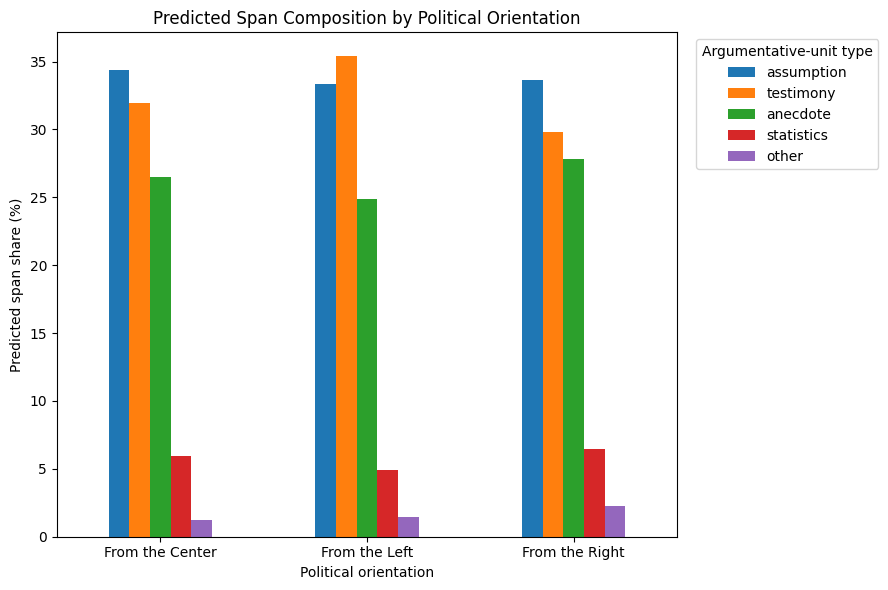

In [11]:
plot_data = orientation_label_percentage.loc[
    ["Center", "Left", "Right"],
    ["assumption", "testimony", "anecdote", "statistics", "other"],
].copy()

plot_data.index = [
    "From the Center",
    "From the Left",
    "From the Right",
]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 6),
)

ax.set_title("Predicted Span Composition by Political Orientation")
ax.set_xlabel("Political orientation")
ax.set_ylabel("Predicted span share (%)")
ax.tick_params(axis="x", rotation=0)

ax.legend(
    title="Argumentative-unit type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    "../figures/allsides_same_events_span_composition_by_orientation.pdf",
    bbox_inches="tight",
)

plt.show()

## 8. Topic Representation

In [12]:
topic_counts = (
    df[["event_id", "topic"]]
    .drop_duplicates()
    ["topic"]
    .value_counts()
)

topic_counts

topic
World                              24
Economy and Jobs                   19
Politics                           13
Donald Trump                       12
Middle East                        10
Defense and Security               10
Immigration                         8
Violence in America                 7
2022 Elections                      7
Criminal Justice                    7
Business                            7
2024 Presidential Election          7
Banking and Finance                 6
Joe Biden                           6
Environment                         6
Media Industry                      5
Justice                             5
Technology                          4
Education                           4
Public Health                       4
Russia                              4
Elections                           4
Energy                              3
China                               3
Race and Racism                     3
Supreme Court                       3
Facts 

In [13]:
topic_thresholds = []

for threshold in [3, 4, 5, 6, 7]:
    retained = topic_counts[topic_counts >= threshold]

    topic_thresholds.append(
        {
            "minimum_events": threshold,
            "topics_retained": len(retained),
            "events_retained": retained.sum(),
            "event_percentage": (retained.sum() / df["event_id"].nunique() * 100),
        }
    )

pd.DataFrame(topic_thresholds).round(2)

,minimum_events,topics_retained,events_retained,event_percentage
0,3,28,197,89.55
1,4,22,179,81.36
2,5,17,159,72.27
3,6,15,149,67.73
4,7,12,131,59.55


In [14]:
retained_topics = topic_counts[topic_counts >= 5].index

len(retained_topics)

17

In [15]:
# subset for the 17 topics 
topic_df = df[df["topic"].isin(retained_topics)]

pd.DataFrame(
    {
        "topics": [topic_df["topic"].nunique()],
        "matched_events": [topic_df["event_id"].nunique()],
        "articles": [topic_df["article_position"].nunique()],
    }
)

,topics,matched_events,articles
0,17,159,477


## 9. Predicted Span Composition by Topic and Political Orientation

In [16]:
topic_orientation_counts = (
    topic_df.groupby(["topic", "orientation", "label"])
    .size()
    .unstack(fill_value=0)
)

topic_orientation_percentage = (
    topic_orientation_counts
    .div(topic_orientation_counts.sum(axis=1), axis=0)
    * 100
).round(2)

topic_orientation_percentage

label                                   anecdote  assumption  other  \
topic                      orientation                                
2022 Elections             Center          27.35       44.49   1.02   
                           Left            20.00       54.40   1.07   
                           Right           31.90       44.80   0.36   
2024 Presidential Election Center          17.10       42.32   0.58   
                           Left            22.26       39.05   3.65   
                           Right           16.36       28.36   7.27   
Banking and Finance        Center          17.96       31.64   1.07   
                           Left            12.72       39.93   1.77   
                           Right           19.09       32.42   0.61   
Business                   Center          27.63       38.39   1.22   
                           Left            31.34       30.25   2.45   
                           Right           38.83       27.66   2.66   
Criminal Justice           Center          40.91       18.18   0.72   
                           Left            36.62       18.31   3.17   
                           Right           41.16       19.39   3.06   
Defense and Security       Center          29.82       29.82   1.75   
                           Left            30.91       19.60   1.21   
                           Right           30.65       23.12   4.02   
Donald Trump               Center          27.79       28.88   0.37   
                           Left            24.35       26.17   2.85   
                           Right           27.60       35.60   1.80   
Economy and Jobs           Center          11.55       36.42   0.73   
                           Left            13.45       37.82   0.66   
                           Right           14.98       35.15   1.61   
Environment                Center          27.79       18.43   1.51   
                           Left            27.99       28.21   0.85   
                           Right           30.43       16.77   4.35   
Immigration                Center          23.37       27.81   1.18   
                           Left            25.00       23.42   1.58   
                           Right           19.74       25.00   0.99   
Joe Biden                  Center          26.70       28.51   0.00   
                           Left            17.96       31.07   0.73   
                           Right           24.14       21.84   2.30   
Justice                    Center          26.09       31.88   1.45   
                           Left            25.17       22.48   1.68   
                           Right           45.52       23.53   0.77   
Media Industry             Center          29.45       34.93   1.37   
                           Left            18.11       58.66   1.57   
                           Right           29.84       41.36   0.52   
Middle East                Center          25.96       24.31   2.56   
                           Left            23.50       21.91   0.53   
                           Right           29.68       19.95   0.97   
Politics                   Center          24.54       39.16   0.50   
                           Left            16.88       47.79   0.95   
                           Right           27.19       47.81   1.25   
Violence in America        Center          38.94       14.04   0.64   
                           Left            36.65        9.95   0.68   
                           Right           41.11        5.56   5.00   
World                      Center          29.40       33.80   1.00   
                           Left            27.41       34.52   0.63   
                           Right           31.13       37.35   1.84   

label                                   statistics  testimony  
topic                      orientation                         
2022 Elections             Center             6.94      20.20  
                           Left             

Predicted span composition varies considerably across topics. Some topics show relatively similar patterns across political orientations, while others display larger differences in the relative use of testimony, assumption, anecdote, and statistics. For example, statistics are particularly prominent in topics such as Banking and Finance and Economy and Jobs, whereas testimony is more prominent in several conflict and security related topics. Because some retained topics contain relatively few matched events, these topic differences are interpreted descriptively.

## 10. Argumentative-Unit Distribution by Topic

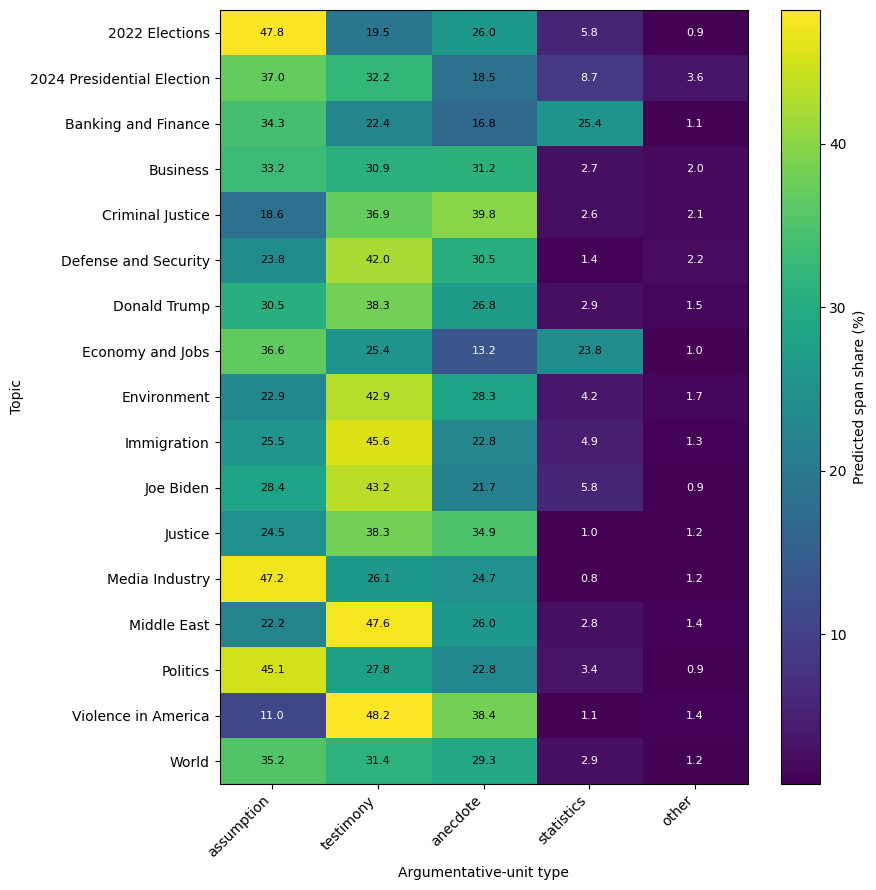

In [17]:
topic_label_counts = (
    topic_df.groupby(["topic", "label"])
    .size()
    .unstack(fill_value=0)
    [["assumption", "testimony", "anecdote", "statistics", "other"]]
)

topic_label_percentage = (
    topic_label_counts
    .div(topic_label_counts.sum(axis=1), axis=0)
    * 100
)

fig, ax = plt.subplots(figsize=(9, 9))

image = ax.imshow(
    topic_label_percentage.values,
    aspect="auto",
    cmap="viridis",
)

ax.set_xticks(range(len(topic_label_percentage.columns)))
ax.set_xticklabels(
    topic_label_percentage.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(range(len(topic_label_percentage.index)))
ax.set_yticklabels(topic_label_percentage.index)

ax.set_xlabel("Argumentative-unit type")
ax.set_ylabel("Topic")

for i in range(len(topic_label_percentage.index)):
    for j in range(len(topic_label_percentage.columns)):
        value = topic_label_percentage.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="black" if value > 15 else "white",
            fontsize=8,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Predicted span share (%)")

plt.tight_layout()

plt.savefig(
    "../figures/allsides_same_events_topic_argumentative_unit_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

The distribution of predicted argumentative-unit types varies substantially across topics. Assumption is especially prominent in topics such as the 2022 Elections, Media Industry, and Politics, whereas testimony is more prominent in Violence in America, the Middle East, and Immigration. Anecdote also accounts for a relatively large share of spans in Criminal Justice and Violence in America. Statistics are generally less frequent but are notably more prominent in Banking and Finance and Economy and Jobs. These patterns indicate that topic provides important context for differences in argumentative-unit composition.

## 11. Outlet Analysis

### 11.1 Outlet Representation

In [18]:
outlet_counts = (
    article_df.groupby(["orientation", "source"])
    .size()
    .reset_index(name="articles")
    .sort_values(["orientation", "articles"], ascending=[True, False])
)

outlet_counts

,orientation,source,articles
25,Center,Newsweek,48
2,Center,BBC News,46
3,Center,CNBC,33
15,Center,Forbes,25
5,Center,Christian Science Monitor,4
...,...,...,...
108,Right,The Blaze,1
112,Right,The Federalist,1
114,Right,Tom Nichols,1
115,Right,Townhall,1


In [19]:
outlet_thresholds = []

for threshold in [3, 5, 10, 15, 20]:
    retained = outlet_counts[outlet_counts["articles"] >= threshold]

    outlet_thresholds.append(
        {
            "minimum_articles": threshold,
            "outlets_retained": len(retained),
            "articles_retained": retained["articles"].sum(),
            "article_percentage": (retained["articles"].sum() / article_df["article_position"].nunique() * 100),
        }
    )

pd.DataFrame(outlet_thresholds).round(2)

,minimum_articles,outlets_retained,articles_retained,article_percentage
0,3,40,560,84.85
1,5,25,506,76.67
2,10,16,446,67.58
3,15,12,399,60.45
4,20,10,365,55.30


In [20]:
retained_outlets = outlet_counts.loc[
    outlet_counts["articles"] >= 5,
    "source",
]

outlet_counts[
    outlet_counts["source"].isin(retained_outlets)
].groupby("orientation").agg(
    outlets=("source", "nunique"),
    articles=("articles", "sum"),
)

,outlets,articles
orientation,,
Center,4,152
Left,12,170
Right,9,184


### 11.2 Predicted Span Composition by Outlet

In [21]:
label_columns = [
    "assumption",
    "testimony",
    "anecdote",
    "statistics",
    "other",
]

article_metadata = (
    df.drop_duplicates("article_position")
    .set_index("article_position")[["source", "orientation"]]
)

outlet_composition = (
    article_composition[label_columns]
    .join(article_metadata)
)

outlet_composition = (
    outlet_composition[
        outlet_composition["source"].isin(retained_outlets)
    ]
    .groupby(["orientation", "source"])[label_columns]
    .mean()
    * 100
)

outlet_composition.round(2)

assumption  testimony  anecdote  \
orientation source                                                     
Center      BBC News                      31.86      33.47     31.71   
            CNBC                          27.47      34.51     18.54   
            Forbes                        36.09      30.86     25.26   
            Newsweek                      23.05      42.71     25.83   
Left        ABC News (Online)              9.38      44.16     42.47   
            Associated Press              29.54      33.38     29.69   
            CBS News (Online)             20.16      45.60     33.47   
            CNN (Online News)             27.34      41.41     25.87   
            CNN Business                  31.78      35.05     15.71   
            CNN Digital                   25.17      36.77     35.20   
            Daily Beast                   31.86      44.71     22.40   
            NBC News (Online)             21.92      47.10     26.47   
            NBC News Digital              24.98      45.03     24.33   
            New York Times (News)         42.09      13.89     23.40   
            The Guardian                  39.91      31.28     23.89   
            USA TODAY                     37.90      34.00     18.83   
Right       Breitbart News                27.75      32.41     30.01   
            Fox Business                  29.38      27.96     24.20   
            Fox News (Online News)        20.86      37.16     34.59   
            Fox News Digital              24.73      32.69     30.98   
            New York Post (News)          24.57      39.51     32.00   
            New York Post (Opinion)       72.79       8.92     11.22   
            The Daily Wire                34.74      34.73     23.60   
            The Epoch Times                4.17       7.64     80.69   
            Washington Examiner           30.52      33.81     23.70   

                                     statistics  other  
orientation source                                      
Center      BBC News                       2.57   0.39  
            CNBC                          18.21   1.27  
            Forbes                         7.28   0.52  
            Newsweek                       6.59   1.82  
Left        ABC News (Online)              1.27   2.72  
            Associated Press               4.78   2.61  
            CBS News (Online)              0.77   0.00  
            CNN (Online News)              4.55   0.83  
            CNN Business                  17.05   0.41  
            CNN Digital                    1.86   1.00  
            Daily Beast                    1.03   0.00  
            NBC News (Online)              4.10   0.42  
            NBC News Digital               5.66   0.00  
            New York Times (News)          3.87  16.75  
            The Guardian                   4.68   0.24  
            USA TODAY                      8.06   1.21  
Right       Breitbart News                 4.98   4.84  
            Fox Business                  15.99   2.46  
            Fox News (Online News)         1.25   6.13  
            Fox News Digital               7.90   3.69  
            New York Post (News)           3.65   0.28  
            New York Post (Opinion)        3.18   3.89  
            The Daily Wire                 6.54   0.38  
            The Epoch Times                0.00   7.50  
            Washington Examiner           11.97   0.00

Predicted argumentative-unit composition varies considerably across outlets, including among outlets assigned to the same political orientation. For example, Center outlets differ in their use of statistics, while Left and Right outlets show notable variation in the relative prominence of assumption, testimony, and anecdote. Several particularly pronounced outlet profiles are also visible, although these should be interpreted cautiously because the retained outlets differ in the number of articles they contribute. Overall, the outlet patterns indicate that political orientation alone does not capture all of the variation in predicted argumentative-unit composition and that individual news organizations provide an important additional context for the orientation-based results.

### 11.3 Predicted Span Density by Outlet

In [22]:
outlet_density = (
    article_df[
        article_df["source"].isin(retained_outlets)
    ]
    .groupby(["orientation", "source"])
    .agg(
        articles=("article_position", "size"),
        mean_density=("spans_per_1000_words", "mean"),
        median_density=("spans_per_1000_words", "median"),
    )
    .round(2)
)

outlet_density

articles  mean_density  median_density
orientation source                                                         
Center      BBC News                       46         65.37           65.95
            CNBC                           33         66.95           68.73
            Forbes                         25         69.31           66.18
            Newsweek                       48         59.33           57.32
Left        ABC News (Online)               7         68.44           66.34
            Associated Press               29         70.91           67.93
            CBS News (Online)               8         68.94           69.02
            CNN (Online News)              38         65.96           64.42
            CNN Business                   16         68.93           69.76
            CNN Digital                     8         57.78           55.65
            Daily Beast                     6         65.96           60.21
            NBC News (Online)              13         58.75           56.34
            NBC News Digital                5         63.19           63.09
            New York Times (News)          18         56.17           54.50
            The Guardian                   12         63.31           62.67
            USA TODAY                      10         68.65           67.48
Right       Breitbart News                  9         59.01           64.94
            Fox Business                   27         64.94           64.59
            Fox News (Online News)         42         59.53           57.96
            Fox News Digital               12         65.93           67.76
            New York Post (News)           37         64.65           64.97
            New York Post (Opinion)         6         72.94           73.49
            The Daily Wire                  5         59.67           60.11
            The Epoch Times                 6         54.83           47.93
            Washington Examiner            40         62.91           62.48

Predicted span density also varies across outlets within each political orientation. Mean density ranges from 59.33 to 69.31 predicted spans per 1,000 words among the retained Center outlets, from 56.17 to 70.91 among Left outlets, and from 54.83 to 72.94 among Right outlets. This within-orientation variation is larger than the differences observed between the three political orientations at the aggregate level, indicating that outlet context is important when interpreting orientation-based patterns. Because outlets contribute different numbers of articles, these results are treated descriptively.

### 11.4 Argumentative-Unit Distribution by Outlet

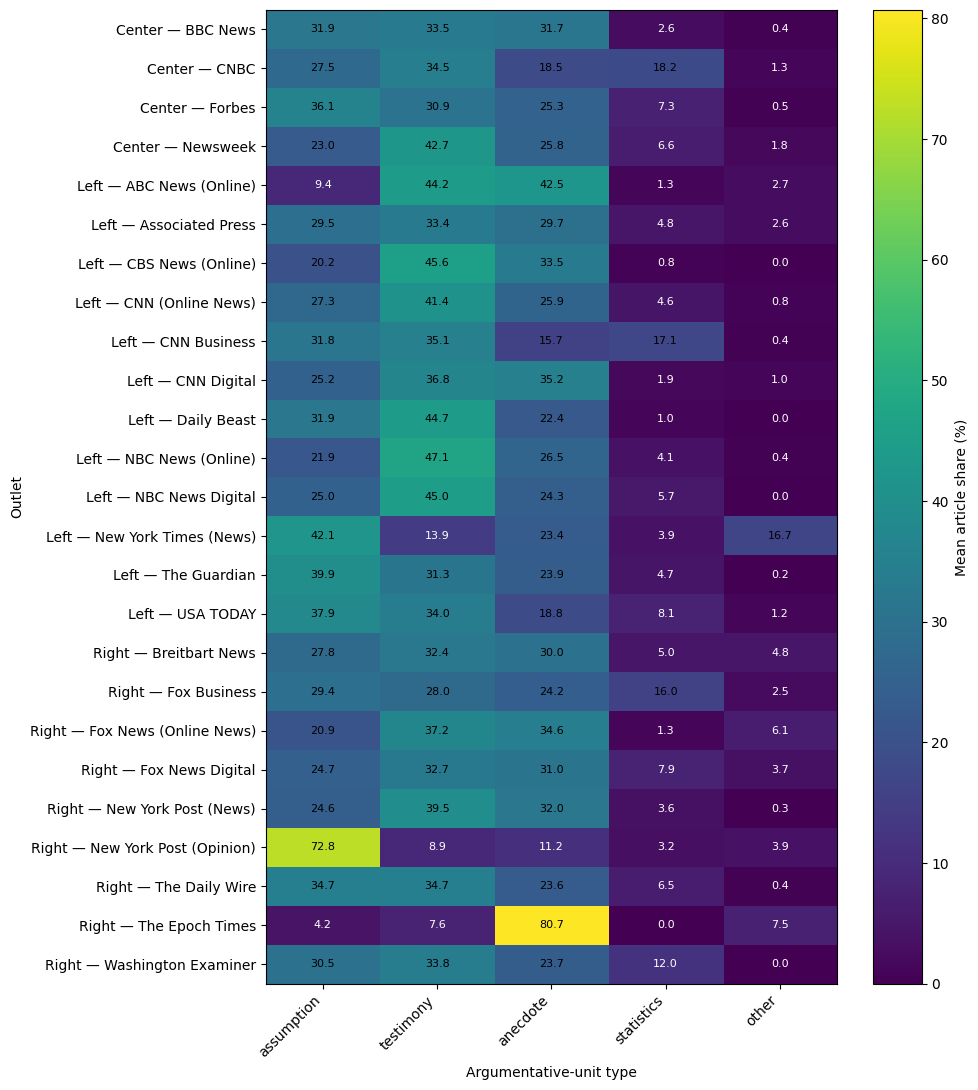

In [23]:
outlet_heatmap = outlet_composition.loc[
    ["Center", "Left", "Right"],
    ["assumption", "testimony", "anecdote", "statistics", "other"],
]

outlet_heatmap.index = [
    f"{orientation} — {source}"
    for orientation, source in outlet_heatmap.index
]

fig, ax = plt.subplots(figsize=(10, 11))

image = ax.imshow(
    outlet_heatmap.values,
    aspect="auto",
    cmap="viridis",
)

ax.set_xticks(range(len(outlet_heatmap.columns)))
ax.set_xticklabels(
    outlet_heatmap.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(range(len(outlet_heatmap.index)))
ax.set_yticklabels(outlet_heatmap.index)

ax.set_xlabel("Argumentative-unit type")
ax.set_ylabel("Outlet")

for i in range(len(outlet_heatmap)):
    for j in range(len(outlet_heatmap.columns)):
        value = outlet_heatmap.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="black" if value > 15 else "white",
            fontsize=8,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Mean article share (%)")

plt.tight_layout()

plt.savefig(
    "../figures/allsides_same_events_outlet_argumentative_unit_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

## 12. Same-Event Comparison

### 12.1 Predicted Span Density Across Matched Events

In [24]:
event_density = (
    article_df.pivot(
        index="event_id",
        columns="orientation",
        values="spans_per_1000_words",
    )
    [["Center", "Left", "Right"]]
)

In [36]:
assert event_density.shape == (df["event_id"].nunique(), 3,)
assert event_density.notna().all().all()

In [25]:
event_density_summary = pd.DataFrame(
    {
        "mean_density": event_density.mean(),
        "median_density": event_density.median(),
    }
)

event_density_summary.round(2)

,mean_density,median_density
orientation,,
Center,64.28,63.77
Left,65.85,63.95
Right,63.54,63.93


In [26]:
density_differences = pd.DataFrame(
    {
        "Center - Left": event_density["Center"] - event_density["Left"],
        "Center - Right": event_density["Center"] - event_density["Right"],
        "Left - Right": event_density["Left"] - event_density["Right"],
    }
)

density_difference_summary = pd.DataFrame(
    {
        "mean_difference": density_differences.mean(),
        "median_difference": density_differences.median(),
        "positive_events": (density_differences > 0).sum(),
        "negative_events": (density_differences < 0).sum(),
    }
)

density_difference_summary.round(2)

,mean_difference,median_difference,positive_events,negative_events
Center - Left,-1.58,-1.33,99,121
Center - Right,0.74,-0.71,103,117
Left - Right,2.31,1.73,118,102


Predicted span density is very similar across matched Left, Center, and Right articles. Left articles have the highest mean density, followed by Center and Right articles, but the average differences are small. Within matched events, Left articles have higher density than Center articles in 121 of 220 events and higher density than Right articles in 118 events. The Center–Right comparison is more mixed, with Right articles having higher density in slightly more events despite Center showing a marginally higher mean overall. These results suggest only modest orientation differences in predicted span density once the news event is held constant.

### 12.2 Argumentative-Unit Composition Across Matched Events

In [27]:
event_composition = (
    article_composition[label_columns]
    .join(
        df.drop_duplicates("article_position")
        .set_index("article_position")[["event_id", "orientation"]]
    )
)

event_composition.head()

,assumption,testimony,anecdote,statistics,other,event_id,orientation
article_position,,,,,,,
1,0.440000,0.200000,0.280000,0.080000,0.000000,1,Left
2,0.333333,0.533333,0.133333,0.000000,0.000000,1,Center
3,0.295775,0.436620,0.183099,0.084507,0.000000,1,Right
4,0.235294,0.529412,0.205882,0.000000,0.029412,2,Left
5,0.290323,0.322581,0.354839,0.000000,0.032258,2,Center


In [28]:
composition_differences = []

for label in label_columns:
    paired = (
        event_composition.pivot(
            index="event_id",
            columns="orientation",
            values=label,
        )
        [["Center", "Left", "Right"]]
        * 100
    )

    for first, second in [
        ("Center", "Left"),
        ("Center", "Right"),
        ("Left", "Right"),
    ]:
        difference = paired[first] - paired[second]

        composition_differences.append(
            {
                "label": label,
                "comparison": f"{first} - {second}",
                "mean_difference": difference.mean(),
                "median_difference": difference.median(),
                "mean_absolute_difference": difference.abs().mean(),
                "first_higher_orientation": (difference > 0).sum(),
                "second_higher_orientation": (difference < 0).sum(),
                "equal_share_events": (difference == 0).sum(),
            }
        )

composition_difference_summary = pd.DataFrame(composition_differences)

composition_difference_summary.round(2)

,label,comparison,mean_difference,median_difference,mean_absolute_difference,first_higher_orientation,second_higher_orientation,equal_share_events
0,assumption,Center - Left,-1.34,-0.55,14.01,105,114,1
1,assumption,Center - Right,1.20,1.28,14.69,119,100,1
2,assumption,Left - Right,2.54,2.31,12.97,129,88,3
3,testimony,Center - Left,0.05,0.00,16.35,109,109,2
4,testimony,Center - Right,2.36,1.69,16.28,119,97,4
5,testimony,Left - Right,2.32,2.12,15.29,120,100,0
6,anecdote,Center - Left,1.38,0.74,11.57,115,104,1
7,anecdote,Center - Right,-1.88,-1.41,12.33,98,121,1
8,anecdote,Left - Right,-3.26,-1.85,12.78,95,122,3
9,statistics,Center - Left,1.30,0.00,4.86,73,66,81


Across matched events, the average directional differences between political orientations are generally modest, but the composition of individual articles can differ substantially. The clearest average patterns are that Left articles contain a somewhat higher share of assumption and testimony than Right articles, while Right articles contain a higher share of anecdote. Differences involving statistics and other are smaller, with many matched events showing equal shares across orientations because these categories are absent from both articles in a substantial number of comparisons. At the same time, the mean absolute differences for assumption, testimony, and anecdote are around 12–16 percentage points, indicating considerable variation between articles covering the same event, even when the average orientation differences are relatively small.

## 13. Statistical Tests

### 13.1 Matched-Event Span Density

In [29]:
from scipy.stats import friedmanchisquare

friedman_density = friedmanchisquare(
    event_density["Center"],
    event_density["Left"],
    event_density["Right"],
)

friedman_density

FriedmanchisquareResult(statistic=np.float64(3.1181818181817107), pvalue=np.float64(0.2103271908521831))

The Friedman test found no statistically significant difference in predicted span density across matched Center, Left, and Right articles, χ²(2) = 3.12, p = .210. This indicates that, once the news event is held constant, overall argumentative-unit density does not differ significantly by political orientation. This result is consistent with the small descriptive differences observed across the three orientations.

### 13.2 Matched-Event Argumentative-Unit Composition

In [31]:
from statsmodels.stats.multitest import multipletests

composition_tests = []

for label in label_columns:
    paired = event_composition.pivot(
        index="event_id",
        columns="orientation",
        values=label,
    )

    test = friedmanchisquare(
        paired["Center"],
        paired["Left"],
        paired["Right"],
    )

    composition_tests.append(
        {
            "label": label,
            "friedman_statistic": test.statistic,
            "p_value": test.pvalue,
        }
    )

composition_test_results = pd.DataFrame(composition_tests)

composition_test_results["holm_corrected_p"] = multipletests(
    composition_test_results["p_value"],
    method="holm",
)[1]

composition_test_results["significant"] = (
    composition_test_results["holm_corrected_p"] < 0.05
)

composition_test_results.round(4)

,label,friedman_statistic,p_value,holm_corrected_p,significant
0,assumption,7.0857,0.0289,0.1447,False
1,testimony,3.0297,0.2198,0.4397,False
2,anecdote,4.6773,0.0965,0.2894,False
3,statistics,0.7109,0.7009,0.7009,False
4,other,5.8795,0.0529,0.2115,False


After correction for multiple comparisons, the Friedman tests found no statistically significant differences in the shares of assumption, testimony, anecdote, statistics, or other spans across matched Center, Left, and Right articles. Although assumption showed a significant uncorrected result, this difference did not remain significant after Holm correction. Taken together with the density analysis, the same-event results provide no evidence of systematic differences in predicted argumentative-unit use by political orientation once the news event is held constant.

In [32]:
n_events = len(event_density)
n_orientations = 3

density_kendalls_w = (
    friedman_density.statistic
    / (n_events * (n_orientations - 1))
)

composition_test_results["kendalls_w"] = (
    composition_test_results["friedman_statistic"]
    / (n_events * (n_orientations - 1))
)

print("Density Kendall's W:", round(density_kendalls_w, 4))

composition_test_results[
    [
        "label",
        "friedman_statistic",
        "p_value",
        "holm_corrected_p",
        "kendalls_w",
        "significant",
    ]
].round(4)

Density Kendall's W: 0.0071


,label,friedman_statistic,p_value,holm_corrected_p,kendalls_w,significant
0,assumption,7.0857,0.0289,0.1447,0.0161,False
1,testimony,3.0297,0.2198,0.4397,0.0069,False
2,anecdote,4.6773,0.0965,0.2894,0.0106,False
3,statistics,0.7109,0.7009,0.7009,0.0016,False
4,other,5.8795,0.0529,0.2115,0.0134,False


Kendall's W effect sizes were very small for both predicted span density and all five argumentative-unit categories. The largest effect was observed for assumption (W = .016), while the remaining values were close to zero. This indicates very weak systematic differences associated with political orientation, reinforcing the non-significant results of the matched-event tests.

In [33]:
density_test_results = pd.DataFrame(
    {
        "friedman_statistic": [friedman_density.statistic],
        "p_value": [friedman_density.pvalue],
        "kendalls_w": [density_kendalls_w],
        "significant": [friedman_density.pvalue < 0.05],
    }
)

density_test_results.to_csv(
    "../results/same_event_density_statistical_test.csv",
    index=False,
)

composition_test_results.to_csv(
    "../results/same_event_composition_statistical_tests.csv",
    index=False,
)